# Data Visualization using Titanic Dataset

In [ ]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data 
df = pd.read_csv('Titanic-Dataset.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


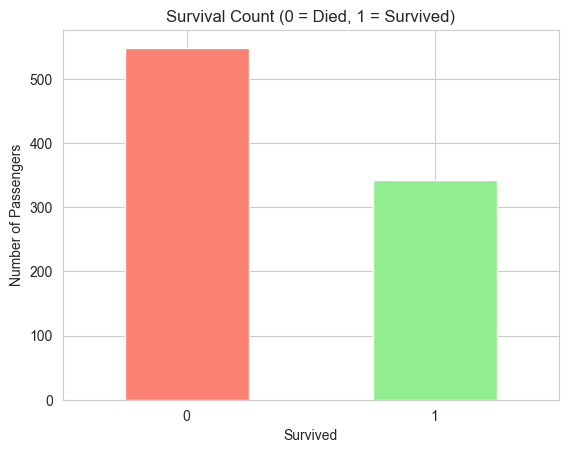

In [ ]:
# Using simple Bar chart for Survival Count 

# Count survived vs not survived
df['Survived'].value_counts().plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Survival Count (0 = Died, 1 = Survived)')
plt.xlabel('Survived')
plt.ylabel('Number of Passengers')
plt.xticks(rotation=0)
plt.show()

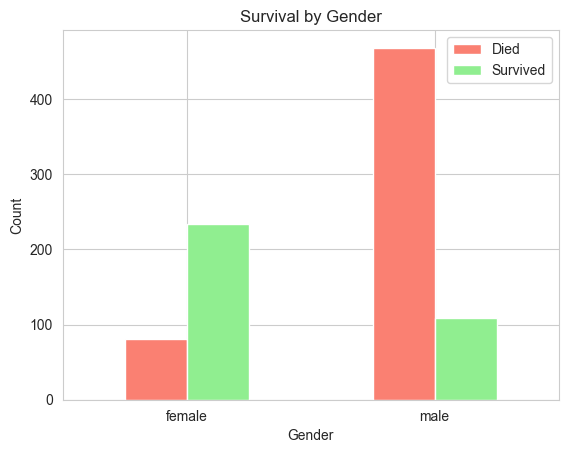

In [ ]:
# Survival by gender

pd.crosstab(df['Sex'], df['Survived']).plot(kind='bar', color=['salmon', 'lightgreen'])
plt.title('Survival by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(['Died', 'Survived'])
plt.xticks(rotation=0)
plt.show()

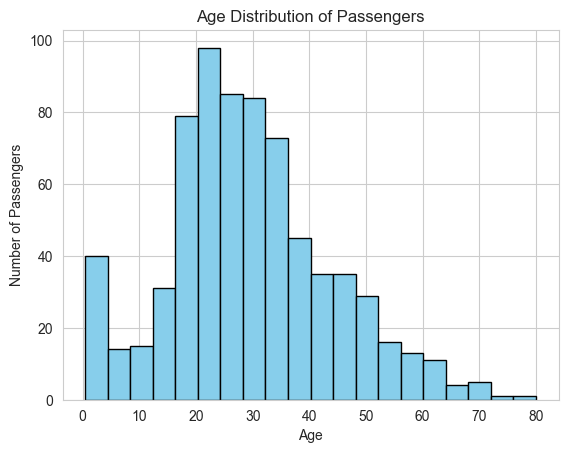

In [6]:
# AgeDistribution using histogram

plt.hist(df['Age'].dropna(), bins=20, color='skyblue', edgecolor='black')
plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Number of Passengers')
plt.show()

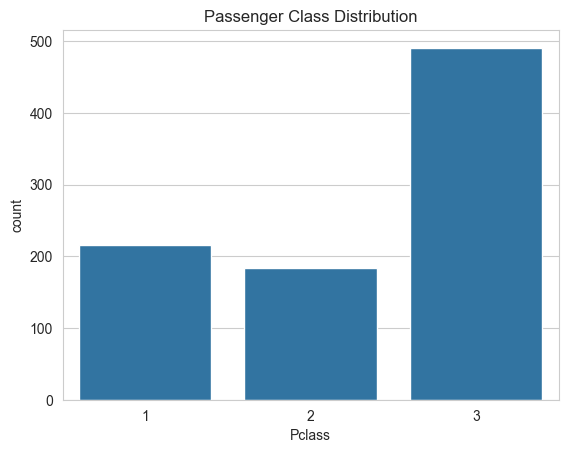

In [10]:
# Passenger class distribution using barchart

sns.countplot(x="Pclass", data=df)

plt.title("Passenger Class Distribution")

plt.show()

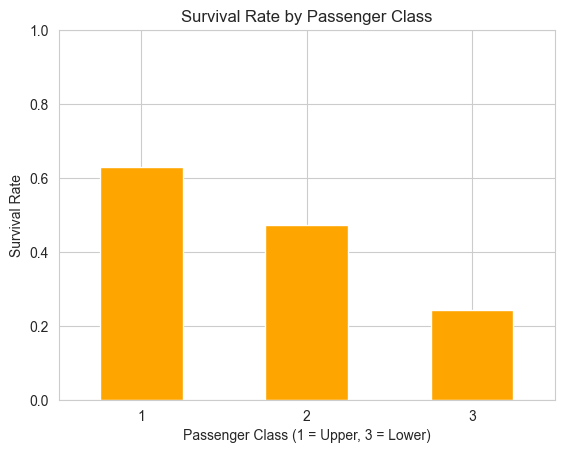

In [8]:
# Survival by passenger class using barchart

df.groupby('Pclass')['Survived'].mean().plot(kind='bar', color='orange')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class (1 = Upper, 3 = Lower)')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.show()

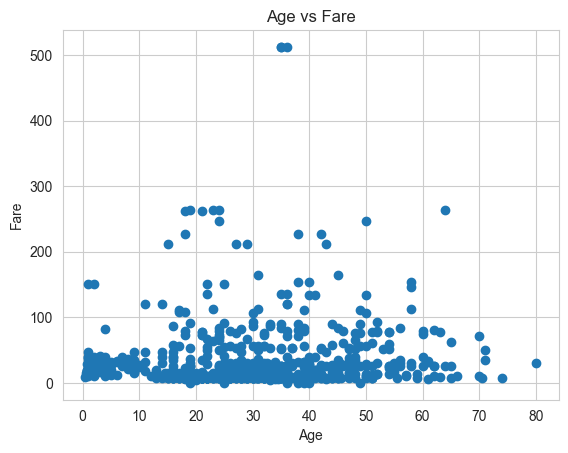

In [11]:
# Age vs Fare using scatter plot

plt.scatter(df["Age"], df["Fare"])

plt.title("Age vs Fare")
plt.xlabel("Age")
plt.ylabel("Fare")

plt.show()

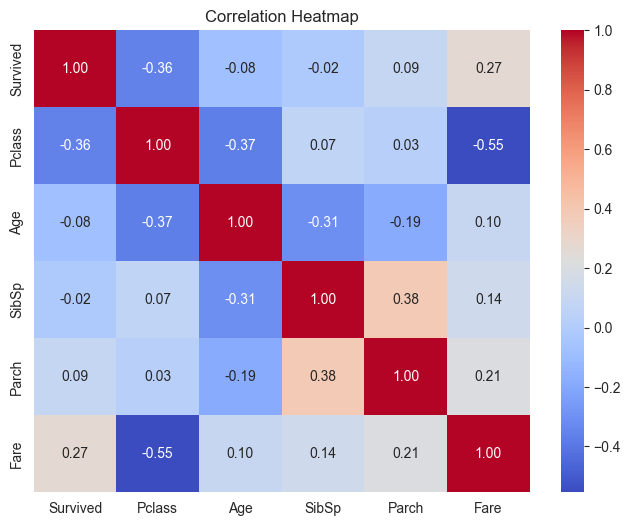

In [9]:
# Heatmap of Correlation between numerical features

numeric_df = df[['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']].dropna()
corr = numeric_df.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

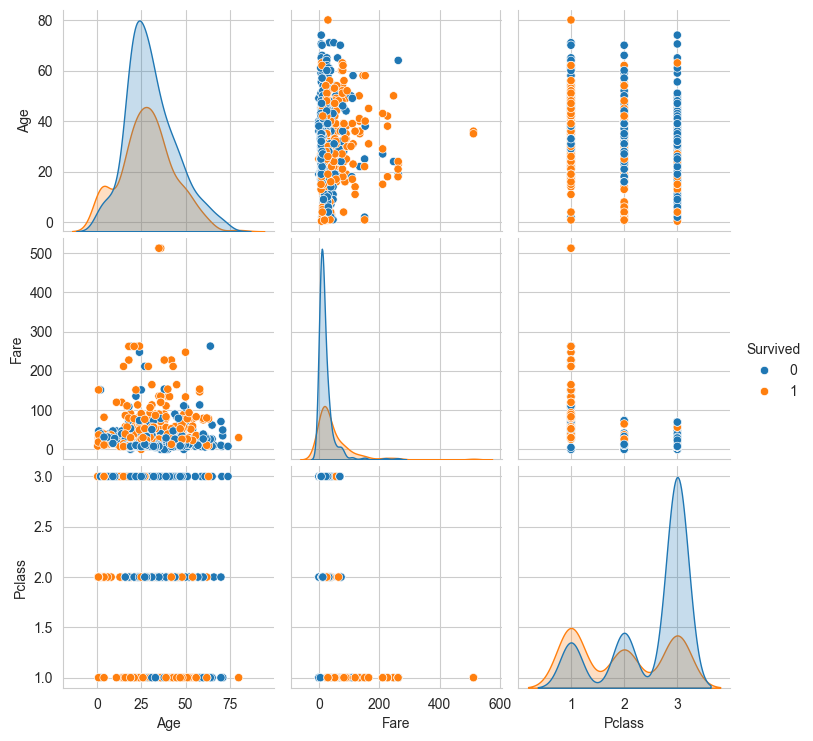

In [12]:
# Pair plot 

sns.pairplot(
    df[["Survived", "Age", "Fare", "Pclass"]],
    hue="Survived"
)

plt.show()

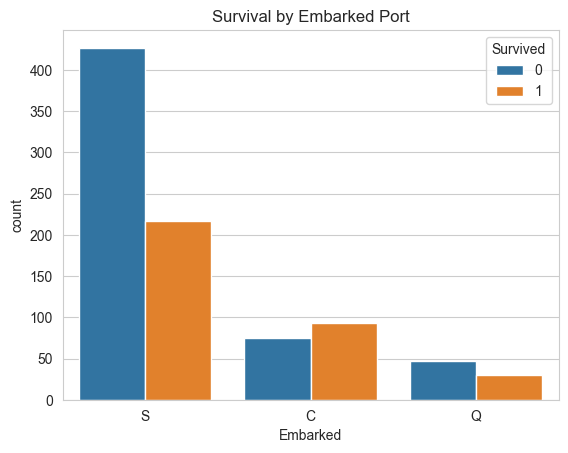

In [13]:
# Embarked port analysis

sns.countplot(x="Embarked", hue="Survived", data=df)

plt.title("Survival by Embarked Port")

plt.show()

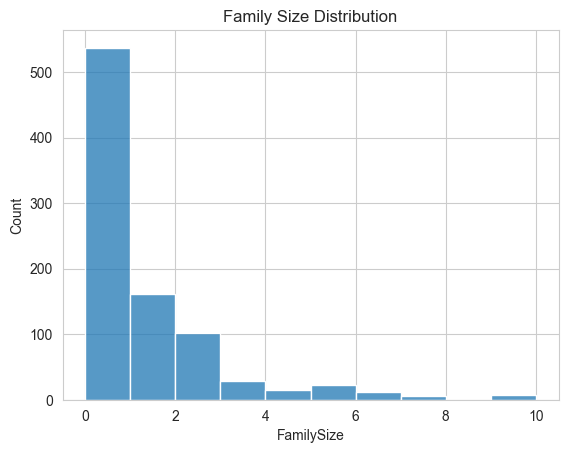

In [14]:
# Family size visualization

df["FamilySize"] = df["SibSp"] + df["Parch"]

sns.histplot(df["FamilySize"], bins=10)

plt.title("Family Size Distribution")

plt.show()

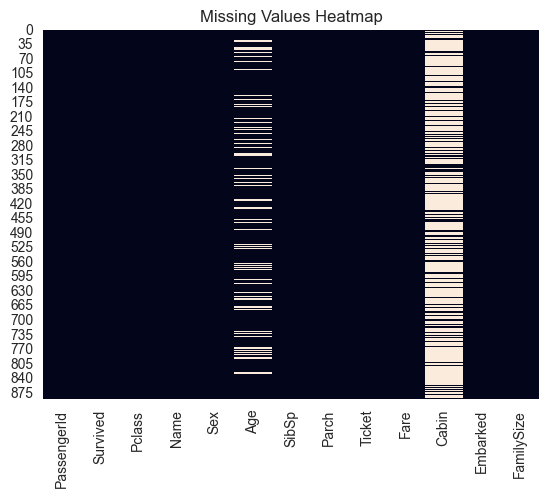

In [15]:
# Cabin missing value analysis

sns.heatmap(df.isnull(), cbar=False)

plt.title("Missing Values Heatmap")

plt.show()

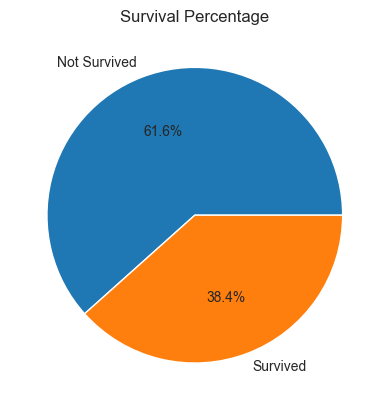

In [16]:
# Pie chart for Survival 

survival_counts = df["Survived"].value_counts()

plt.pie(
    survival_counts,
    labels=["Not Survived", "Survived"],
    autopct="%1.1f%%"
)

plt.title("Survival Percentage")

plt.show()

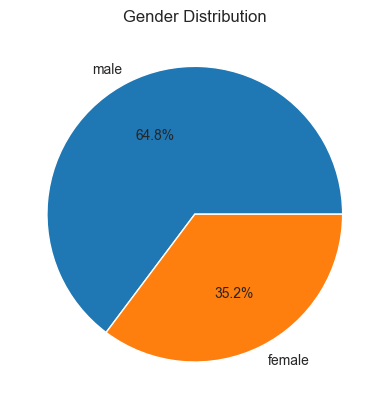

In [18]:
# Gender distribution Piechart

gender_counts = df["Sex"].value_counts()

plt.pie(
    gender_counts,
    labels=gender_counts.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.show()

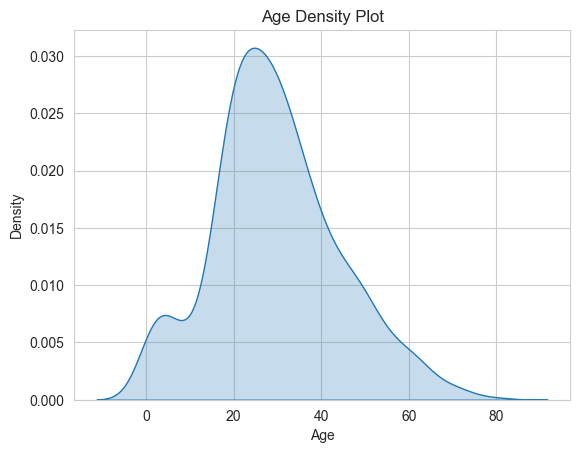

In [19]:
# KDE plot for Age

sns.kdeplot(df["Age"].dropna(), fill=True)

plt.title("Age Density Plot")

plt.show()

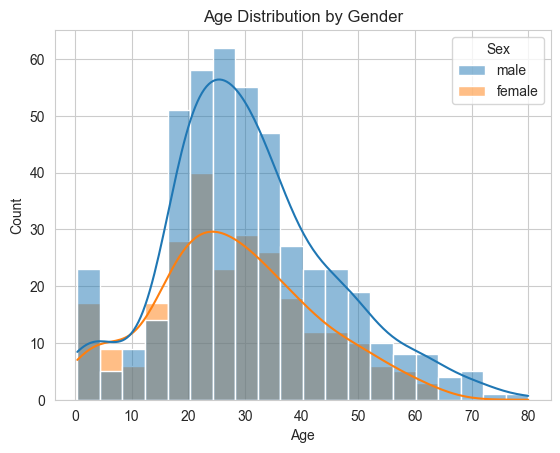

In [20]:
# Age distribution by gender

sns.histplot(
    data=df,
    x="Age",
    hue="Sex",
    bins=20,
    kde=True
)

plt.title("Age Distribution by Gender")

plt.show()

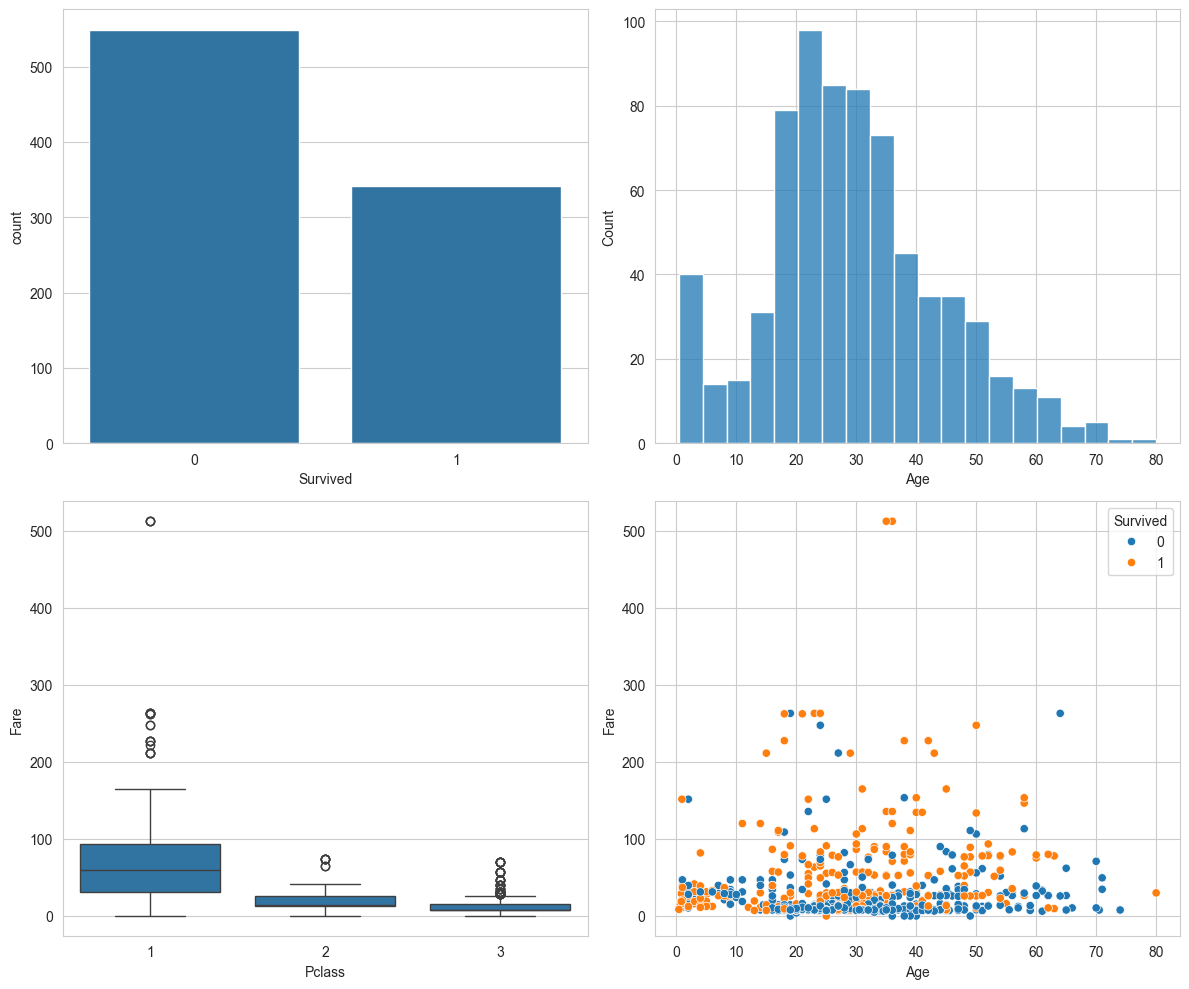

In [21]:
# Final summary visualization

fig, axes = plt.subplots(2, 2, figsize=(12,10))

sns.countplot(x="Survived", data=df, ax=axes[0,0])

sns.histplot(df["Age"].dropna(), bins=20, ax=axes[0,1])

sns.boxplot(x="Pclass", y="Fare", data=df, ax=axes[1,0])

sns.scatterplot(x="Age", y="Fare", hue="Survived", data=df, ax=axes[1,1])

plt.tight_layout()

plt.show()